In [13]:
%reload_ext autoreload
%autoreload 2

In [14]:
# Polarimetry Testing Data Augmentation — Masks + nM + nM11s Only


In [15]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import json

# Add lib path (relative to current working directory)
lib_path = Path("../lib")
if lib_path.exists():
    sys.path.insert(0, str(lib_path.absolute()))

# Import the augmenter (it will handle Mueller imports internally)
from processing.data_augment import PolarimetryDataAugmenter

In [16]:
SOURCE_DIRECTORY = Path("/Volumes/ep_ssd/MPL_Data/mmNoTissueFilter/testing")
OUTPUT_DIRECTORY = Path("/Volumes/ep_ssd/MPL_Data/mmNoTissueFilter/testing/augmented")

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(f"Source: {SOURCE_DIRECTORY}")
print(f"Output: {OUTPUT_DIRECTORY}")


Source: /Volumes/ep_ssd/MPL_Data/mmNoTissueFilter/testing
Output: /Volumes/ep_ssd/MPL_Data/mmNoTissueFilter/testing/augmented


In [17]:
print("\n=== INITIALIZING AUGMENTER ===")

try:
    # Since lib is in sys.path, import with the full module path
    from polar_augment.flip_mm import RandomMuellerFlip
    from polar_augment.rotation_mm import RandomMuellerRotation
    print("Successfully imported Mueller matrix functions")
except ImportError as e:
    import logging
    logger = logging.getLogger("PolarimetryDataAugmenter")
    logger.warning(f"Mueller matrix functions not available: {e}")
    RandomMuellerFlip = None
    RandomMuellerRotation = None


=== INITIALIZING AUGMENTER ===
Successfully imported Mueller matrix functions


In [18]:
print("=== SCANNING SOURCE DIRECTORY ===")
sample_files = []
for subdir in sorted(SOURCE_DIRECTORY.iterdir()):
    if subdir.is_dir():
        npz_candidates = sorted(subdir.glob("*.npz"))
        if npz_candidates:
            sample_files.append(max(npz_candidates, key=lambda p: p.stat().st_size))

sample_dirs = [f.parent for f in sample_files]

print(f"Found {len(sample_files)} samples to process:")
for i, f in enumerate(sample_files):
    print(f"  {i+1}: {f.parent.name} ({f.name})")


=== SCANNING SOURCE DIRECTORY ===
Found 110 samples to process:
  1: D18_L2_D18_S3_PSG_conf_20um_10avg_1000P_5x_a6_22-Apr-2020_PSG6procZ_MM_R_C (SAMMM.npz)
  2: D18_L2_D18_S3_PSG_conf_20um_10avg_1000P_5x_a6_22-Apr-2020_PSG6procZ_MM_R_C copy (SAMMM.npz)
  3: D18_L3_D18_S1_PSG_conf_fov9_3avg_1000P_5x_a6_23-Apr-2020_PSG6procZ_MM_R_C (SAMMM.npz)
  4: D18_L3_D18_S1_PSG_conf_fov9_3avg_1000P_5x_a6_23-Apr-2020_PSG6procZ_MM_R_C copy (SAMMM.npz)
  5: D18_L3_D18_S3_PSG_conf_fov6_10avg_1000P_5x_a6_23-Apr-2020_PSG6procZ_MM_R_C (SAMMM.npz)
  6: D18_L3_D18_S3_PSG_conf_fov6_10avg_1000P_5x_a6_23-Apr-2020_PSG6procZ_MM_R_C copy (SAMMM.npz)
  7: D18_L5_D18_S1_PSG_conf_fov9_5avg_1000P_5x_a6_23-Apr-2020_PSG6procZ_MM_R_C (SAMMM.npz)
  8: D18_L5_D18_S1_PSG_conf_fov9_5avg_1000P_5x_a6_23-Apr-2020_PSG6procZ_MM_R_C copy (SAMMM.npz)
  9: D18_L5_D18_S3_PSG_conf_fov9_5avg_1000P_5x_a6_23-Apr-2020_PSG6procZ_MM_R_C (SAMMM.npz)
  10: D18_L5_D18_S3_PSG_conf_fov9_5avg_1000P_5x_a6_23-Apr-2020_PSG6procZ_MM_R_C copy (SAMMM.n

In [19]:
print("\n=== INSPECTING SAMPLE STRUCTURE ===")
if sample_files:
    sample_path = sample_files[0]
    print(f"Loading: {sample_path.parent.name}/{sample_path.name}")
    with np.load(sample_path, allow_pickle=True) as data:
        print("\nKeys and shapes:")
        for key in data.keys():
            value = data[key]
            if isinstance(value, np.ndarray):
                print(f"  {key}: {value.shape} (dtype: {value.dtype})")
            else:
                print(f"  {key}: {type(value)}")
    sample_data = np.load(sample_path, allow_pickle=True)
    nM = sample_data['nM']
    print(f"\nnM shape: {nM.shape}")
    if len(nM.shape) == 3 and nM.shape[-1] == 16:
        print("  -> Needs reshaping from (H, W, 16) to (H, W, 4, 4)")
    elif len(nM.shape) == 4 and nM.shape[-2:] == (4, 4):
        print("  -> Already in (H, W, 4, 4) format")
    if 'M11s' in sample_data.keys():
        M11s = sample_data['M11s']
        print(f"\nFound M11s: {M11s.shape}")
        print(f"  M11s range: [{np.min(M11s):.4f}, {np.max(M11s):.4f}]")
        print(f"  -> Will apply 0-1 normalization")
    elif 'nM11s' in sample_data.keys():
        nM11s = sample_data['nM11s']
        print(f"\nFound nM11s: {nM11s.shape}")
        print(f"  nM11s range: [{np.min(nM11s):.4f}, {np.max(nM11s):.4f}]")
        print(f"  -> Already normalized")



=== INSPECTING SAMPLE STRUCTURE ===
Loading: D18_L2_D18_S3_PSG_conf_20um_10avg_1000P_5x_a6_22-Apr-2020_PSG6procZ_MM_R_C/SAMMM.npz

Keys and shapes:
  nM: (500, 500, 4, 4) (dtype: float64)
  M11s: (500, 500) (dtype: float64)
  Mdepols: (500, 500) (dtype: float64)
  Mdiattenuations: (500, 500) (dtype: float64)
  Morientations: (500, 500) (dtype: float64)
  SHGZ: (500, 500) (dtype: float64)
  TPEFZ: (500, 500) (dtype: float64)
  linrs: (500, 500) (dtype: float64)
  fSHGZ: (500, 500) (dtype: float64)
  fTPEFZ: (500, 500) (dtype: float64)
  fM11s: (500, 500) (dtype: float64)
  flinrs: (500, 500) (dtype: float64)
  fnM: (500, 500, 16) (dtype: float64)
  fMdepols: (500, 500) (dtype: float64)
  fMdiattenuations: (500, 500) (dtype: float64)
  fMorientations: (500, 500) (dtype: float64)
  denoise_meta: () (dtype: object)
  tissue_mask: (500, 500) (dtype: bool)
  tissue_mask_date: () (dtype: <U26)
  tissue_mask_pixels: () (dtype: int64)

nM shape: (500, 500, 4, 4)
  -> Already in (H, W, 4, 4) fo

In [20]:
print("\n=== DEFINING AUGMENTATION STRATEGY ===")
MUELLER_KEYS = ['nM']  # only nM uses polarimetric-aware transforms

augmentation_configs = [
    {'name': 'original'},
    {'name': 'rot90', 'rotation_angle': 90},
    {'name': 'rot180', 'rotation_angle': 180},
    {'name': 'rot270', 'rotation_angle': 270},
    {'name': 'flip_h', 'flip_orientation': 0},
    {'name': 'flip_v', 'flip_orientation': 1},

    # --- CROPPING AUGS DISABLED ---
    # {'name': 'quarters', 'crop_to_quarters': True, 'crop_type': 'quarters'},
    # {'name': 'centers', 'crop_to_quarters': True, 'crop_type': 'centers'},
    # {'name': 'rot90_quarters', 'rotation_angle': 90, 'crop_to_quarters': True, 'crop_type': 'quarters'},
    # {'name': 'rot90_centers', 'rotation_angle': 90, 'crop_to_quarters': True, 'crop_type': 'centers'},
    # {'name': 'flip_h_quarters', 'flip_orientation': 0, 'crop_to_quarters': True, 'crop_type': 'quarters'},
    # {'name': 'flip_v_centers', 'flip_orientation': 1, 'crop_to_quarters': True, 'crop_type': 'centers'},
]

print(f"Defined {len(augmentation_configs)} augmentation types")
samples_without_cropping = sum(1 for cfg in augmentation_configs if not cfg.get('crop_to_quarters', False))
samples_with_quarters = sum(1 for cfg in augmentation_configs if cfg.get('crop_type') == 'quarters')
samples_with_centers = sum(1 for cfg in augmentation_configs if cfg.get('crop_type') == 'centers')
expected_per_sample = (samples_without_cropping + (samples_with_quarters * 4) + (samples_with_centers * 4))
total_expected = len(sample_dirs) * expected_per_sample
print(f"Expected output per sample: {expected_per_sample} files")
print(f"Total expected files: {total_expected} files")



=== DEFINING AUGMENTATION STRATEGY ===
Defined 6 augmentation types
Expected output per sample: 6 files
Total expected files: 660 files


In [21]:
def find_mask_keys(d):
    """Binary/categorical masks end with '_mask'."""
    return [k for k in d.keys() if isinstance(d[k], np.ndarray) and k.endswith('_mask')]

ALWAYS_SAVE_KEYS = {'nM', 'nM11s'}

def build_allowed_keys(data_dict):
    """Masks + nM + nM11s."""
    return set(find_mask_keys(data_dict)).union(ALWAYS_SAVE_KEYS)

def filter_allowed(data_dict, allowed_keys):
    """Filter dict to allowed arrays only."""
    return {k: v for k, v in data_dict.items() if k in allowed_keys}


In [22]:
def prepare_sample_data(data_dict):
    """Prepare sample data, reshaping nM and normalizing M11s to nM11s if necessary."""
    prepared_dict = data_dict.copy()

    # nM reshape
    if 'nM' in prepared_dict:
        nM = prepared_dict['nM']
        if len(nM.shape) == 3 and nM.shape[-1] == 16:
            H, W, _ = nM.shape
            prepared_dict['nM'] = nM.reshape(H, W, 4, 4)
            print(f"  Reshaped nM from {nM.shape} to {prepared_dict['nM'].shape}")
        elif len(nM.shape) == 4 and nM.shape[-2:] == (4, 4):
            print(f"  nM already in correct format: {nM.shape}")
        else:
            print(f"  WARNING: Unexpected nM shape: {nM.shape}")

    # M11s normalization → nM11s
    if 'M11s' in prepared_dict and 'nM11s' not in prepared_dict:
        M11s = prepared_dict['M11s']
        M11s_min = np.min(M11s)
        M11s_max = np.max(M11s)
        if M11s_max > M11s_min:
            nM11s = (M11s - M11s_min) / (M11s_max - M11s_min)
        else:
            nM11s = M11s.copy()
        prepared_dict['nM11s'] = nM11s
        prepared_dict['M11s_normalization'] = {
            'min': float(M11s_min),
            'max': float(M11s_max),
            'normalized_from': 'M11s'
        }
        print(f"  Created nM11s (normalized): range [{np.min(nM11s):.4f}, {np.max(nM11s):.4f}]")
    elif 'nM11s' in prepared_dict:
        vals = prepared_dict['nM11s']
        print(f"  Found nM11s (already normalized): range [{np.min(vals):.4f}, {np.max(vals):.4f}]")

    return prepared_dict


In [23]:
def process_all_samples():
    print(f"\n=== STARTING BATCH PROCESSING ===")
    print(f"Processing {len(sample_dirs)} samples")
    print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    augmenter = PolarimetryDataAugmenter(log_level="INFO") 

    stats = {
        'samples_processed': 0,
        'samples_failed': 0,
        'augmentations_created': 0,
        'augmentations_failed': 0,
        'total_files_created': 0,
        'samples_with_M11s': 0,
        'samples_with_nM11s': 0,
        'start_time': datetime.now(),
        'failed_samples': [],
        'failed_augmentations': []
    }

    for sample_idx, sample_file in enumerate(sample_files):
        sample_name = sample_file.parent.name
        print(f"\n[{sample_idx + 1}/{len(sample_files)}] Processing: {sample_name}")
        print(f"    Loading: {sample_file.name}")

        try:
            with np.load(sample_file, allow_pickle=True) as data:
                original_data = {key: data[key] for key in data.keys()}

            if 'M11s' in original_data and 'nM11s' not in original_data:
                stats['samples_with_M11s'] += 1
            elif 'nM11s' in original_data:
                stats['samples_with_nM11s'] += 1

            # Prepare
            original_data = prepare_sample_data(original_data)

            # Decide augmentation + save policy
            mask_keys = find_mask_keys(original_data)  # e.g., annotation_mask, tissue_mask, os_mask
            allowed_keys = build_allowed_keys(original_data)  # masks + nM + nM11s

            mueller_keys = ['nM']
            regular_keys = mask_keys + (['nM11s'] if 'nM11s' in original_data else [])

            sample_files_created = 0

            def save_filtered_result(result, folder_suffix):
                to_save = filter_allowed(result, allowed_keys)
                if 'nM' in to_save and to_save['nM'].ndim == 3 and to_save['nM'].shape[-1] == 16:
                    H, W, _ = to_save['nM'].shape
                    to_save['nM'] = to_save['nM'].reshape(H, W, 4, 4)
                folder_name = f"{sample_name}_{folder_suffix}"
                output_folder = OUTPUT_DIRECTORY / folder_name
                output_folder.mkdir(parents=True, exist_ok=True)
                output_file = output_folder / "SAMMM.npz"
                augmenter.save_augmented_data(to_save, output_file)
                return 1

            # Augmentation loop
            for aug_idx, aug_config in enumerate(augmentation_configs):
                try:
                    aug_params = aug_config.copy()
                    aug_params['mueller_keys'] = mueller_keys
                    aug_params['regular_keys'] = regular_keys

                    results = augmenter.augment_sample(original_data, aug_params)

                    if isinstance(results, list):
                        for result in results:
                            crop_region = result.get('crop_region', 'unknown')
                            folder_suffix = f"{aug_config['name']}_{crop_region}"
                            sample_files_created += save_filtered_result(result, folder_suffix)
                    else:
                        folder_suffix = f"{aug_config['name']}"
                        sample_files_created += save_filtered_result(results, folder_suffix)

                    stats['augmentations_created'] += 1

                except Exception as e:
                    print(f"    ERROR in {aug_config['name']}: {e}")
                    stats['augmentations_failed'] += 1
                    stats['failed_augmentations'].append({
                        'sample': sample_name,
                        'augmentation': aug_config['name'],
                        'error': str(e)
                    })

            print(f"    Created {sample_files_created} files")
            stats['samples_processed'] += 1
            stats['total_files_created'] += sample_files_created

        except Exception as e:
            print(f"    FAILED to process sample: {e}")
            stats['samples_failed'] += 1
            stats['failed_samples'].append({
                'sample': sample_name,
                'error': str(e)
            })

    stats['end_time'] = datetime.now()
    stats['processing_time'] = stats['end_time'] - stats['start_time']
    return stats


In [24]:
processing_stats = process_all_samples()


2025-10-24 08:56:13,086 - PolarimetryDataAugmenter - INFO - Successfully imported Mueller matrix augmentation functions



=== STARTING BATCH PROCESSING ===
Processing 110 samples
Started at: 2025-10-24 08:56:13

[1/110] Processing: D18_L2_D18_S3_PSG_conf_20um_10avg_1000P_5x_a6_22-Apr-2020_PSG6procZ_MM_R_C
    Loading: SAMMM.npz
  nM already in correct format: (500, 500, 4, 4)
  Created nM11s (normalized): range [0.0000, 1.0000]
    Created 6 files

[2/110] Processing: D18_L2_D18_S3_PSG_conf_20um_10avg_1000P_5x_a6_22-Apr-2020_PSG6procZ_MM_R_C copy
    Loading: SAMMM.npz
  nM already in correct format: (500, 500, 4, 4)
  Created nM11s (normalized): range [0.0000, 1.0000]
    Created 6 files

[3/110] Processing: D18_L3_D18_S1_PSG_conf_fov9_3avg_1000P_5x_a6_23-Apr-2020_PSG6procZ_MM_R_C
    Loading: SAMMM.npz
  nM already in correct format: (500, 500, 4, 4)
  Created nM11s (normalized): range [0.0000, 1.0000]
    Created 6 files

[4/110] Processing: D18_L3_D18_S1_PSG_conf_fov9_3avg_1000P_5x_a6_23-Apr-2020_PSG6procZ_MM_R_C copy
    Loading: SAMMM.npz
  nM already in correct format: (500, 500, 4, 4)
  Created n

In [25]:
print(f"\n=== BATCH PROCESSING COMPLETE ===")
print(f"Processing time: {processing_stats['processing_time']}")
print(f"Samples processed: {processing_stats['samples_processed']}")
print(f"Samples failed: {processing_stats['samples_failed']}")
print(f"Augmentations created: {processing_stats['augmentations_created']}")
print(f"Augmentations failed: {processing_stats['augmentations_failed']}")
print(f"Total files created: {processing_stats['total_files_created']}")
print(f"\nData Type Distribution:")
print(f"  Samples with M11s (normalized to nM11s): {processing_stats['samples_with_M11s']}")
print(f"  Samples with nM11s (pre-normalized): {processing_stats['samples_with_nM11s']}")
total_attempts = processing_stats['samples_processed'] + processing_stats['samples_failed']
success_rate = (processing_stats['samples_processed'] / total_attempts * 100) if total_attempts > 0 else 0
print(f"Sample success rate: {success_rate:.1f}%")



=== BATCH PROCESSING COMPLETE ===
Processing time: 1:05:37.990721
Samples processed: 110
Samples failed: 0
Augmentations created: 660
Augmentations failed: 0
Total files created: 660

Data Type Distribution:
  Samples with M11s (normalized to nM11s): 24
  Samples with nM11s (pre-normalized): 84
Sample success rate: 100.0%


In [26]:
print(f"\n=== SAVING PROCESSING REPORT ===")
created_dirs = list(OUTPUT_DIRECTORY.glob("*"))
aug_type_counts = {}
for directory in created_dirs:
    for cfg in augmentation_configs:
        if cfg['name'] in directory.name:
            aug_type = cfg['name']
            aug_type_counts[aug_type] = aug_type_counts.get(aug_type, 0) + 1
            break

report = {
    'processing_summary': {
        'start_time': processing_stats['start_time'].isoformat(),
        'end_time': processing_stats['end_time'].isoformat(),
        'processing_time_seconds': processing_stats['processing_time'].total_seconds(),
        'samples_processed': processing_stats['samples_processed'],
        'samples_failed': processing_stats['samples_failed'],
        'augmentations_created': processing_stats['augmentations_created'],
        'augmentations_failed': processing_stats['augmentations_failed'],
        'total_files_created': processing_stats['total_files_created'],
        'samples_with_M11s': processing_stats['samples_with_M11s'],
        'samples_with_nM11s': processing_stats['samples_with_nM11s'],
        'success_rate_percent': success_rate
    },
    'configuration': {
        'source_directory': str(SOURCE_DIRECTORY),
        'output_directory': str(OUTPUT_DIRECTORY),
        'mueller_keys': MUELLER_KEYS,
        'augmentation_configs': augmentation_configs,
        'total_source_samples': len(sample_dirs),
        'keep_only_note': "Outputs contain only *_mask, nM, nM11s"
    },
    'output_analysis': {
        'augmentation_type_counts': aug_type_counts,
        'total_output_directories': len(created_dirs)
    },
    'errors': {
        'failed_samples': processing_stats.get('failed_samples', []),
        'failed_augmentations': processing_stats.get('failed_augmentations', [])
    }
}

report_file = OUTPUT_DIRECTORY / "augmentation_report.json"
with open(report_file, 'w') as f:
    json.dump(report, f, indent=2)

print(f"Processing report saved to: {report_file}")
print(f"\nFiles by augmentation type:")
for aug_type in sorted(aug_type_counts.keys()):
    count = aug_type_counts[aug_type]
    print(f"  {aug_type}: {count} files")



=== SAVING PROCESSING REPORT ===
Processing report saved to: /Volumes/ep_ssd/MPL_Data/mmNoTissueFilter/testing/augmented/augmentation_report.json

Files by augmentation type:
  flip_h: 220 files
  flip_v: 220 files
  original: 220 files
  rot180: 220 files
  rot270: 220 files
  rot90: 220 files



=== VISUALIZING SAMPLE AUGMENTATIONS ===
Visualizing augmentations for: D18_L2_D18_S3_PSG_conf_20um_10avg_1000P_5x_a6_22-Apr-2020_PSG6procZ_MM_R_C


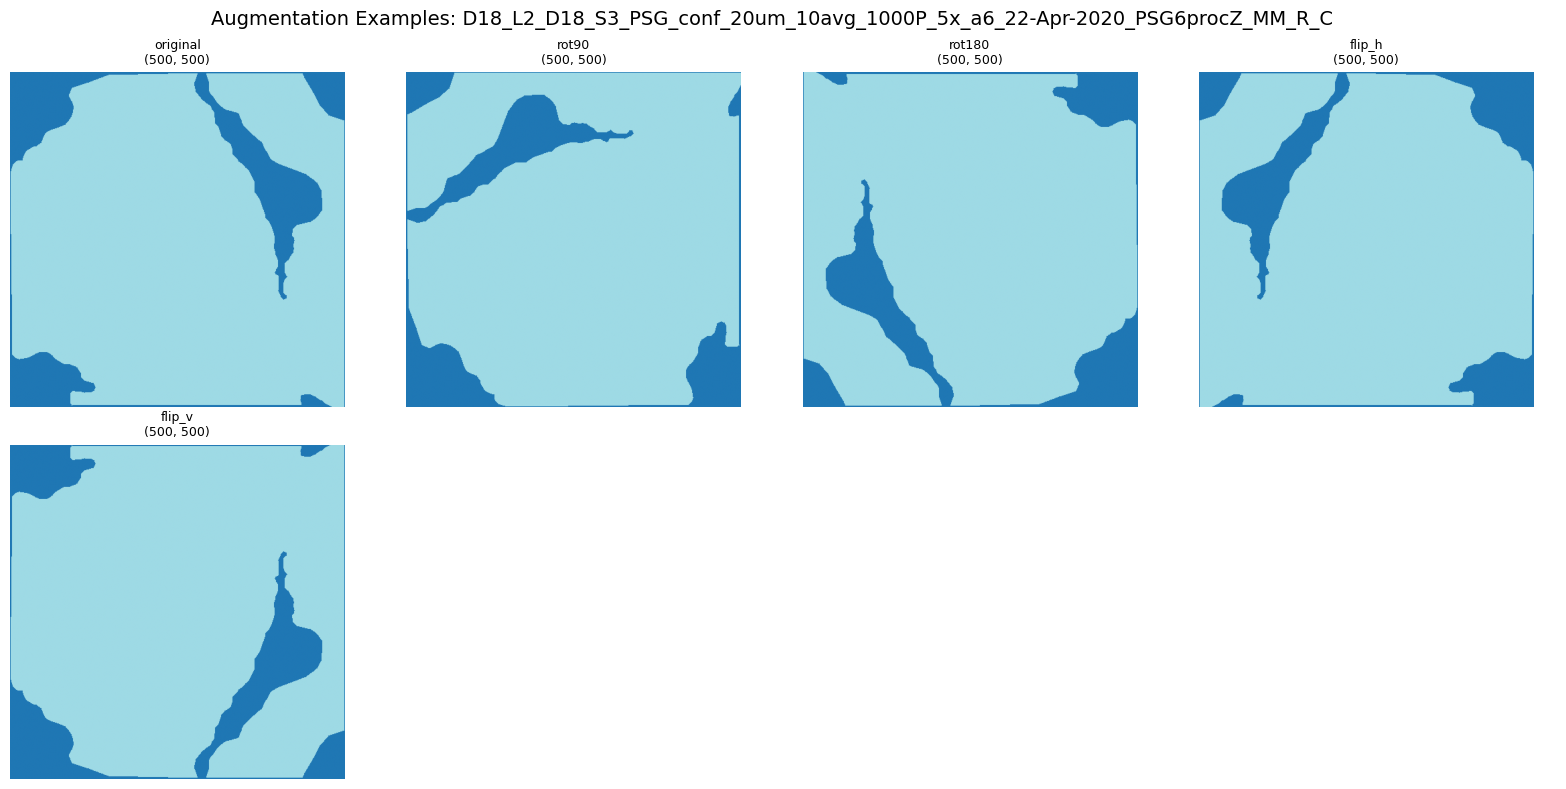

In [27]:
print(f"\n=== VISUALIZING SAMPLE AUGMENTATIONS ===")
if sample_dirs:
    sample_to_visualize = sample_dirs[0].name
    print(f"Visualizing augmentations for: {sample_to_visualize}")
    created_dirs = list(OUTPUT_DIRECTORY.glob("*"))
    sample_variants = [d for d in created_dirs if d.name.startswith(sample_to_visualize)]

    priority_augs = ['original', 'rot90', 'rot180', 'flip_h', 'flip_v',
                     'quarters_top_left', 'centers_top_center']

    display_variants = []
    for priority in priority_augs:
        matching = [v for v in sample_variants if priority in v.name]
        if matching:
            display_variants.append(matching[0])

    if display_variants:
        n_variants = min(len(display_variants), 8)
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.flatten()
        fig.suptitle(f'Augmentation Examples: {sample_to_visualize}', fontsize=14)

        for i, variant_dir in enumerate(display_variants[:8]):
            try:
                npz_files = list(variant_dir.glob("*.npz"))
                if not npz_files:
                    axes[i].axis('off')
                    continue
                npz_file = npz_files[0]
                with np.load(npz_file, allow_pickle=True) as data:
                    if 'annotation_mask' in data:
                        img_data = data['annotation_mask']; cmap = 'tab20'
                    elif 'tissue_mask' in data:
                        img_data = data['tissue_mask']; cmap = 'tab20'
                    elif 'os_mask' in data:
                        img_data = data['os_mask']; cmap = 'tab20'
                    elif 'nM11s' in data:
                        img_data = data['nM11s']; cmap = 'hot'
                    else:
                        img_data = None
                    if img_data is not None:
                        axes[i].imshow(img_data, cmap=cmap)
                        aug_name = variant_dir.name.replace(sample_to_visualize + '_', '')
                        axes[i].set_title(f"{aug_name}\n{img_data.shape}", fontsize=9)
                        axes[i].axis('off')
                    else:
                        axes[i].axis('off')
            except Exception as e:
                axes[i].text(0.5, 0.5, f"Error\n{str(e)[:50]}", ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title("Error", fontsize=9)

        for i in range(len(display_variants), 8):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()


In [28]:
print(f"\n=== AUGMENTATION COMPLETE ===")
print(f"- Processed {processing_stats['samples_processed']} testing samples")
print(f"- Created {processing_stats['total_files_created']} augmented files")
print(f"- Outputs limited to: *_mask, nM, nM11s")
print(f"- nM stored as (H, W, 4, 4)")


=== AUGMENTATION COMPLETE ===
- Processed 110 testing samples
- Created 660 augmented files
- Outputs limited to: *_mask, nM, nM11s
- nM stored as (H, W, 4, 4)
